## Test FFT reconstruction

This notebook tests the implementation and main features of the fft_reconstruction class

In [1]:
import sys
import os
os.environ["DEBUG_LOGGER"] = "True"

# NumPy 2.x compatibility
import numpy as np
np.product = np.prod
np.asfarray = np.asarray

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import camb as camb

In [2]:
sys.path.insert(0,'/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/')


In [3]:
from zeldareco.utils.mock_generator import generate_gaussian_map, generate_lognormal_map
from zeldareco.displacement_solver.fft_solver import FFTSolver
from zeldareco.mesh.mesh import Mesh
from zeldareco.mesh.field_ops import smoothed_field

In [4]:
n_mesh = 256
box_size = 1024  # Mpc/h

cell_size = int(box_size / n_mesh)
print('cell_size:', cell_size)
boxcentre=[box_size//2, box_size//2, box_size//2]

LOS = 'z'

redshift = 1.0

cell_size: 4


Let's instantiate a Mesh object

In [5]:
mesh_obj = Mesh(los=LOS, nmesh=n_mesh, boxsize=box_size, boxcentre=boxcentre, dtype=np.float32)

mesh_obj.print_info()

2026-05-11 17:51:21,182 - zeldareco.mesh.mesh - INFO - Mesh Information:
2026-05-11 17:51:21,183 - zeldareco.mesh.mesh - INFO - Boxsize: 1024 Mpc/h
2026-05-11 17:51:21,183 - zeldareco.mesh.mesh - INFO - Number of grid points: 256
2026-05-11 17:51:21,184 - zeldareco.mesh.mesh - INFO - Cell size: 4.0 Mpc/h
2026-05-11 17:51:21,184 - zeldareco.mesh.mesh - INFO - Boxcentre: [512. 512. 512.]
2026-05-11 17:51:21,185 - zeldareco.mesh.mesh - INFO - Line-of-sight: z


# Smoothed density

#### generate a density field

In [6]:
Omega_b= 0.05
Omega_c = 0.25
h=0.7
As = 2.1e-09
ns = 0.96

pars = camb.CAMBparams()
pars.set_cosmology(H0=100*h, ombh2=Omega_b*h**2, omch2=Omega_c*h**2)
pars.InitPower.set_params(As=As, ns=ns)

class: <InitialPowerLaw>
 tensor_parameterization = tensor_param_rpivot
 ns = 0.96
 nrun = 0.0
 nrunrun = 0.0
 nt = -0.0
 ntrun = -0.0
 r = 0.0
 pivot_scalar = 0.05
 pivot_tensor = 0.05
 As = 2.1e-09
 At = 1.0
 

In [7]:
pars.set_matter_power(redshifts=[redshift], kmax=100.)
result = camb.get_results(pars)

kh, z, pk = result.get_matter_power_spectrum(minkh=1.e-4, maxkh=100, npoints=512)

# define power spectrum interpolator
pk_func = interp1d(kh, pk[0], fill_value='extrapolate', kind='cubic')

In [34]:
hubble = result.hubble_parameter(z=redshift)
growth_rate = float(result.get_fsigma8()/result.get_sigma8())
print('hubble:', hubble)
print('growth_rate:', growth_rate)

hubble: 123.45269376854759
growth_rate: 0.8711917202205977


/tmp/ipykernel_1292700/2560428912.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  growth_rate = float(result.get_fsigma8()/result.get_sigma8())


Text(0.5, 1.0, 'linear matter power spectrum')

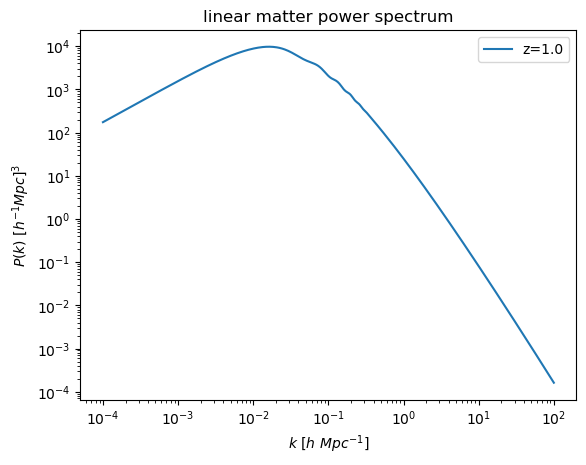

In [9]:
plt.loglog(kh, pk_func(kh), label='z={}'.format(redshift))
plt.legend()
plt.xlabel('$k \ [h\ Mpc^{-1}]$')
plt.ylabel('$P(k)\  [h^{-1}Mpc]^3$')
plt.title('linear matter power spectrum')

In [10]:
ln_delta_x = generate_lognormal_map(pk_func, side=box_size, spacing=int(cell_size))
delta_k_gauss, delta_x_gauss = generate_gaussian_map(pk_func, side=box_size, spacing=int(cell_size)) 

mean of G_x is =  -1.6517142471458857e-18
variance of G_x is =  0.8132692518620996


In [11]:
print(np.mean(ln_delta_x))

3.912177588458926e-05


Pdf of the delta field: gaussian vs lognormal

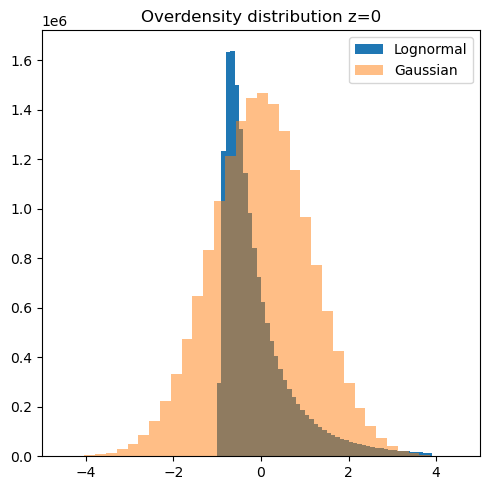

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

# Plot the density distribution at z=0
bin_edges = [-2 + 0.1*i for i in range(60)]
axs.hist(ln_delta_x.flatten(), bins=bin_edges, density=False, label='Lognormal')
axs.hist(delta_x_gauss.flatten(), bins=50, density=False, alpha=0.5, label='Gaussian')
axs.legend()
axs.set_xlim(-5, 5)
axs.set_title('Overdensity distribution z=0')

plt.tight_layout()
plt.show()

In [13]:
np.min(ln_delta_x), np.max(ln_delta_x)

(-0.9952782995246097, 75.8747244525252)

In [18]:
R_smooth  = 10 # Mpc/h 

smoothed_delta_field = smoothed_field(ln_delta_x, mesh=mesh_obj, smoothing_radius=R_smooth)

2026-05-11 17:53:31,521 - zeldareco.mesh.field_ops - DEBUG - Applying FFT-based Gaussian smoothing with PBC.
2026-05-11 17:53:32,888 - zeldareco.mesh.field_ops - DEBUG - kmesh shape in _gaussian_kernel is  (256, 256, 129, 3)


# Real Space

In [19]:
# Direct (RealSpace) FFT reconstruction
recon_real = FFTSolver(
    delta_on_mesh=smoothed_delta_field, 
    mesh=mesh_obj, 
    f=growth_rate, 
    bias=1.0,
    RSDspace='RealSpace'
)

print(f"FFT Solver (RealSpace) initialized")
print(f"Growth rate: {recon_real.f}")
print(f"Bias: {recon_real.bias}")

FFT Solver (RealSpace) initialized
Growth rate: [0.87119172]
Bias: 1.0


Check the smoothing

In [20]:
smoothed_delta_field.min(), smoothed_delta_field.max()

(-0.6698772141339501, 2.715330235190133)

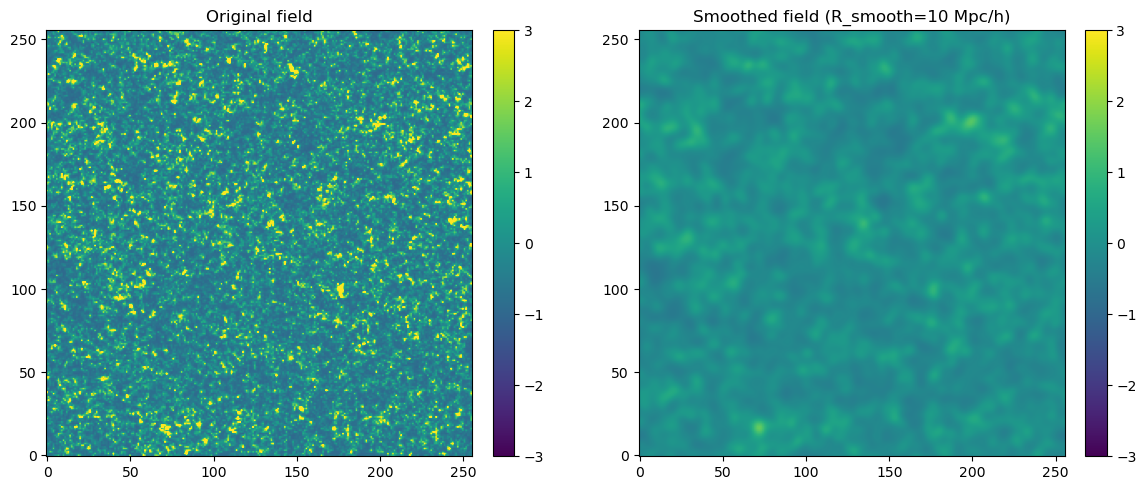

In [21]:
# plot the original delta and the smoothed delta in the same figure
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im0 = ax[0].imshow(ln_delta_x[:, :, n_mesh//2], origin='lower', cmap='viridis', norm=Normalize(vmin=-3, vmax=3))
ax[0].set_title('Original field')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
im1 = ax[1].imshow(smoothed_delta_field[:, :, n_mesh//2], origin='lower', cmap='viridis', norm=Normalize(vmin=-3, vmax=3))
ax[1].set_title('Smoothed field (R_smooth={} Mpc/h)'.format(R_smooth))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Plot the histogram of the smoothed and unsmoothed delta field

Text(0.5, 0, 'Overdensity')

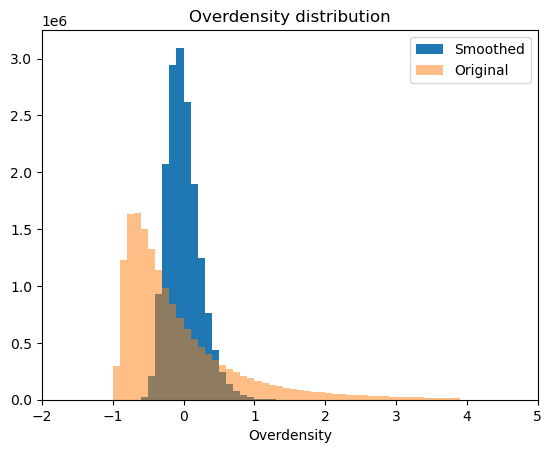

In [22]:
bin_edges = [-2 + 0.1*i for i in range(60)]
plt.hist(smoothed_delta_field.flatten(), bins=bin_edges, density=False, label='Smoothed')
plt.hist(ln_delta_x.flatten(), bins=bin_edges, density=False, alpha=0.5, label='Original')
plt.xlim(-2, 5)
plt.legend()
plt.title('Overdensity distribution')
plt.xlabel('Overdensity')

## Displacement

In [23]:
psi_real = recon_real.displacement
phi_real = recon_real.potential

print(f"Displacement shape: {psi_real.shape}")
print(f"Potential shape: {phi_real.shape}")
print(f"Displacement range: [{psi_real.min():.4f}, {psi_real.max():.4f}]")
print(f"Potential range: [{phi_real.min():.4f}, {phi_real.max():.4f}]")

2026-05-11 17:53:48,772 - zeldareco.displacement_solver.poisson_solver - DEBUG - Computing displacement via _compute() or from potential
2026-05-11 17:53:48,773 - zeldareco.displacement_solver.fft_solver - DEBUG - Using direct estimation of displacement field (FFT).


Displacement shape: (256, 256, 256, 3)
Potential shape: (256, 256, 256)
Displacement range: [-13.0341, 12.7612]
Potential range: [-1138.1302, 1016.5404]


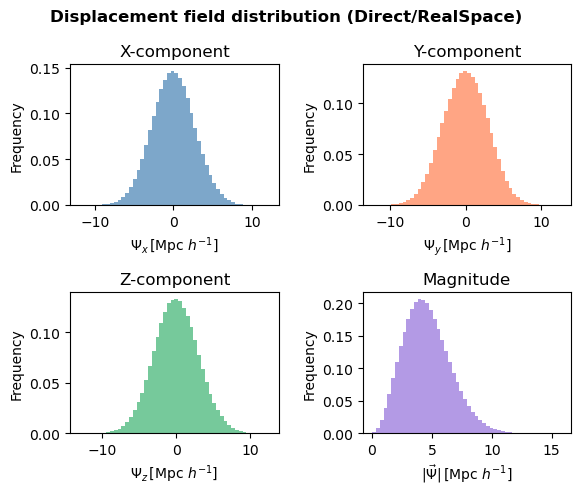

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(6, 5))

# Plot histogram of x-component of velocity field
axs[0, 0].hist(psi_real[..., 0].flatten(), bins=50, density=True, color='steelblue', alpha=0.7)
axs[0, 0].set_xlabel(r'$\Psi_x\, [\mathrm{Mpc}~h^{-1}]$')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].set_title('X-component')

# Plot histogram of y-component of velocity field
axs[0, 1].hist(psi_real[..., 1].flatten(), bins=50, density=True, color='coral', alpha=0.7)
axs[0, 1].set_xlabel(r'$\Psi_y\, [\mathrm{Mpc}~h^{-1}]$')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].set_title('Y-component')

# Plot histogram of z-component of velocity field
axs[1, 0].hist(psi_real[..., 2].flatten(), bins=50, density=True, color='mediumseagreen', alpha=0.7)
axs[1, 0].set_xlabel(r'$\Psi_z\, [\mathrm{Mpc}~h^{-1}]$')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].set_title('Z-component')

# Plot histogram of norm of velocity field
psi_norm_real = np.linalg.norm(psi_real, axis=-1)
axs[1, 1].hist(psi_norm_real.flatten(), bins=50, density=True, color='mediumpurple', alpha=0.7)
axs[1, 1].set_xlabel(r'$|\vec{\Psi}| \, [\mathrm{Mpc}~h^{-1}]$')
axs[1, 1].set_ylabel('Frequency')
axs[1, 1].set_title('Magnitude')

fig.suptitle('Displacement field distribution (Direct/RealSpace)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Potential 
The scalar potential is computed from the density field: $\phi = -\delta / (k^2 \cdot \text{bias})$


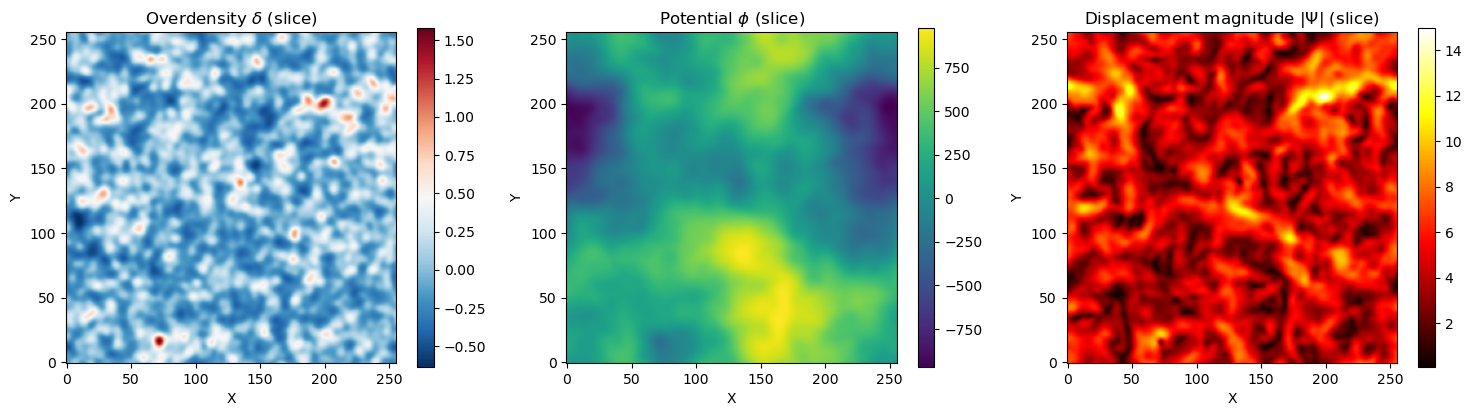

Potential statistics:
  Mean: 0.000000
  Std: 343.676868
  Min: -1138.130193, Max: 1016.540433


In [25]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

mid_slice = n_mesh // 2

# Plot density field
im0 = axs[0].imshow(smoothed_delta_field[:, :, mid_slice], origin='lower', cmap='RdBu_r')
axs[0].set_title(r'Overdensity $\delta$ (slice)')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
plt.colorbar(im0, ax=axs[0])

# Plot potential field
im1 = axs[1].imshow(phi_real[:, :, mid_slice], origin='lower', cmap='viridis')
axs[1].set_title(r'Potential $\phi$ (slice)')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
plt.colorbar(im1, ax=axs[1])

# Plot displacement magnitude
psi_mag = np.linalg.norm(psi_real, axis=-1)
im2 = axs[2].imshow(psi_mag[:, :, mid_slice], origin='lower', cmap='hot')
axs[2].set_title(r'Displacement magnitude $|\Psi|$ (slice)')
axs[2].set_xlabel('X')
axs[2].set_ylabel('Y')
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

# Potential statistics
print(f"Potential statistics:")
print(f"  Mean: {phi_real.mean():.6f}")
print(f"  Std: {phi_real.std():.6f}")
print(f"  Min: {phi_real.min():.6f}, Max: {phi_real.max():.6f}")

# Redshift Space

Test iterative reconstruction in RedshiftSpace with different growth rates:
- $f=0$ --> we check the result is equivalent to RealSpace
- $f\neq0$ --> should be different than RealSpace


In [30]:
# Iterative reconstruction with f=0 (effective RealSpace)
recon_iter_f0 = FFTSolver(
    delta_on_mesh=smoothed_delta_field, 
    mesh=mesh_obj,
    f=0.0, 
    bias=1.0,
    RSDspace='RedshiftSpace'
)

# Iterative reconstruction with f=growth_rate (true RSD)
recon_iter_RSD = FFTSolver(
    delta_on_mesh=smoothed_delta_field, 
    mesh=mesh_obj,
    f=growth_rate, 
    bias=1.0,
    RSDspace='RedshiftSpace'
)

print(f"Iterative solvers initialized")


Iterative solvers initialized


In [31]:
# Extract displacement fields (lazy evaluation triggers computation)
psi_iter_f0 = recon_iter_f0.displacement
psi_iter_RSD = recon_iter_RSD.displacement

print(f"Computed displacement fields")
print(f"f=0 shape: {psi_iter_f0.shape}, range: [{psi_iter_f0.min():.4f}, {psi_iter_f0.max():.4f}]")
print(f"RSD shape: {psi_iter_RSD.shape}, range: [{psi_iter_RSD.min():.4f}, {psi_iter_RSD.max():.4f}]")

2026-05-11 17:57:17,178 - zeldareco.displacement_solver.poisson_solver - DEBUG - Computing displacement via _compute() or from potential
2026-05-11 17:57:17,178 - zeldareco.displacement_solver.fft_solver - DEBUG - Computing displacement iteratively (RSD), iterations=3
2026-05-11 17:57:17,562 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 1
2026-05-11 17:57:36,607 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 2
2026-05-11 17:57:45,557 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 3
2026-05-11 17:57:55,209 - zeldareco.displacement_solver.poisson_solver - DEBUG - Computing displacement via _compute() or from potential
2026-05-11 17:57:55,210 - zeldareco.displacement_solver.fft_solver - DEBUG - Computing displacement iteratively (RSD), iterations=3
2026-05-11 17:57:55,604 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 1
2026-05-11 17:57:59,960 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 2
2026-05-11 17:58:

Computed displacement fields
f=0 shape: (256, 256, 256, 3), range: [-13.0341, 12.7612]
RSD shape: (256, 256, 256, 3), range: [-10.6978, 11.2433]


## Iterative convergence check

We verify convergence of the iterative FFT method by increasing the number of iterations and measuring how much the displacement field changes between successive runs.


2026-05-11 18:11:32,754 - zeldareco.displacement_solver.fft_solver - DEBUG - Computing displacement iteratively (RSD), iterations=8
2026-05-11 18:11:33,154 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 1
2026-05-11 18:11:37,175 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 2
2026-05-11 18:11:42,458 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 3
2026-05-11 18:11:46,718 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 4
2026-05-11 18:11:51,654 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 5
2026-05-11 18:11:56,733 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 6
2026-05-11 18:12:01,568 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 7
2026-05-11 18:12:05,760 - zeldareco.displacement_solver.fft_solver - DEBUG - Iteration 8
2026-05-11 18:12:15,858 - zeldareco.displacement_solver.fft_solver - DEBUG - Computing displacement iteratively (RSD), iterations=1
2026-05-11 18:12:16,281 

Iterative convergence check (reference = 8 iterations):
  n_iterations= 1 | absolute diff = 9.937737e+02 | relative diff = 6.028264e-02
  n_iterations= 2 | absolute diff = 3.736920e+02 | relative diff = 2.266828e-02
  n_iterations= 3 | absolute diff = 2.161964e+02 | relative diff = 1.311454e-02
  n_iterations= 5 | absolute diff = 9.703969e+01 | relative diff = 5.886460e-03


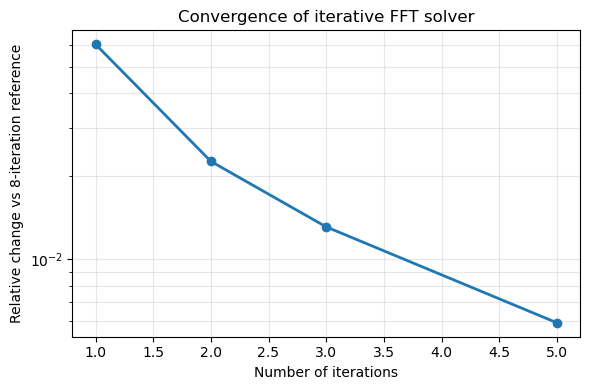

In [44]:
# Use a smaller sweep to keep the notebook reasonably fast
iteration_grid = [1, 2, 3, 5]
reference_iterations = 8
convergence_results = []

reference_solver = FFTSolver(
    delta_on_mesh=smoothed_delta_field,
    mesh=mesh_obj,
    f=growth_rate,
    bias=1.0,
    RSDspace='RedshiftSpace'
)
reference_solver._compute_displacement_iterative_potential(n_iterations=reference_iterations)
reference_field = reference_solver.displacement
reference_norm = np.linalg.norm(reference_field)

for n_iter in iteration_grid:
    solver = FFTSolver(
        delta_on_mesh=smoothed_delta_field,
        mesh=mesh_obj,
        f=growth_rate,
        bias=1.0,
        RSDspace='RedshiftSpace'
    )
    solver._compute_displacement_iterative_potential(n_iterations=n_iter)
    psi_n = solver.displacement
    diff = np.linalg.norm(psi_n - reference_field)
    rel_diff = diff / (reference_norm + 1e-12)
    convergence_results.append((n_iter, diff, rel_diff))

print(f'Iterative convergence check (reference = {reference_iterations} iterations):')
for n_iter, diff, rel_diff in convergence_results:
    print(f'  n_iterations={n_iter:2d} | absolute diff = {diff:.6e} | relative diff = {rel_diff:.6e}')

iters = [row[0] for row in convergence_results]
rel_errors = [row[2] for row in convergence_results]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(iters, rel_errors, marker='o', linewidth=2)
ax.set_xlabel('Number of iterations')
ax.set_ylabel(f'Relative change vs {reference_iterations}-iteration reference')
ax.set_title('Convergence of iterative FFT solver')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [33]:
growth_rate

array([0.87119172])

In [35]:
# Compare all three reconstructions
psi_final = psi_real  # Direct reconstruction
psi_iter_0 = psi_iter_f0  # Iterative with f=0
psi_iter_rsd = psi_iter_RSD  # Iterative with f=growth_rate

# Compute summary statistics
def compute_stats(psi_field, label):
    psi_norm = np.linalg.norm(psi_field, axis=-1)
    return {
        'label': label,
        'mean_x': psi_field[..., 0].mean(),
        'std_x': psi_field[..., 0].std(),
        'mean_y': psi_field[..., 1].mean(),
        'std_y': psi_field[..., 1].std(),
        'mean_z': psi_field[..., 2].mean(),
        'std_z': psi_field[..., 2].std(),
        'mean_mag': psi_norm.mean(),
        'std_mag': psi_norm.std(),
    }

stats_real = compute_stats(psi_real, 'Direct/RealSpace')
stats_f0 = compute_stats(psi_iter_f0, 'Iterative f=0')
stats_rsd = compute_stats(psi_iter_RSD, f'Iterative f={growth_rate:.4f}')

print("\nDisplacement Field Statistics:")
for stats in [stats_real, stats_f0, stats_rsd]:
    print(f"\n{stats['label']}:")
    print(f"  X: μ={stats['mean_x']:8.4f}, σ={stats['std_x']:8.4f}")
    print(f"  Y: μ={stats['mean_y']:8.4f}, σ={stats['std_y']:8.4f}")
    print(f"  Z: μ={stats['mean_z']:8.4f}, σ={stats['std_z']:8.4f}")
    print(f"  |Ψ|: μ={stats['mean_mag']:8.4f}, σ={stats['std_mag']:8.4f}")


Displacement Field Statistics:

Direct/RealSpace:
  X: μ= -0.0000, σ=  2.7172
  Y: μ= -0.0000, σ=  2.9401
  Z: μ=  0.0000, σ=  2.9598
  |Ψ|: μ=  4.5916, σ=  1.9247

Iterative f=0:
  X: μ= -0.0000, σ=  2.7172
  Y: μ= -0.0000, σ=  2.9401
  Z: μ=  0.0000, σ=  2.9598
  |Ψ|: μ=  4.5916, σ=  1.9247

Iterative f=0.8712:
  X: μ= -0.0000, σ=  2.3492
  Y: μ= -0.0000, σ=  2.6051
  Z: μ= -0.0000, σ=  2.0312
  |Ψ|: μ=  3.7339, σ=  1.5778


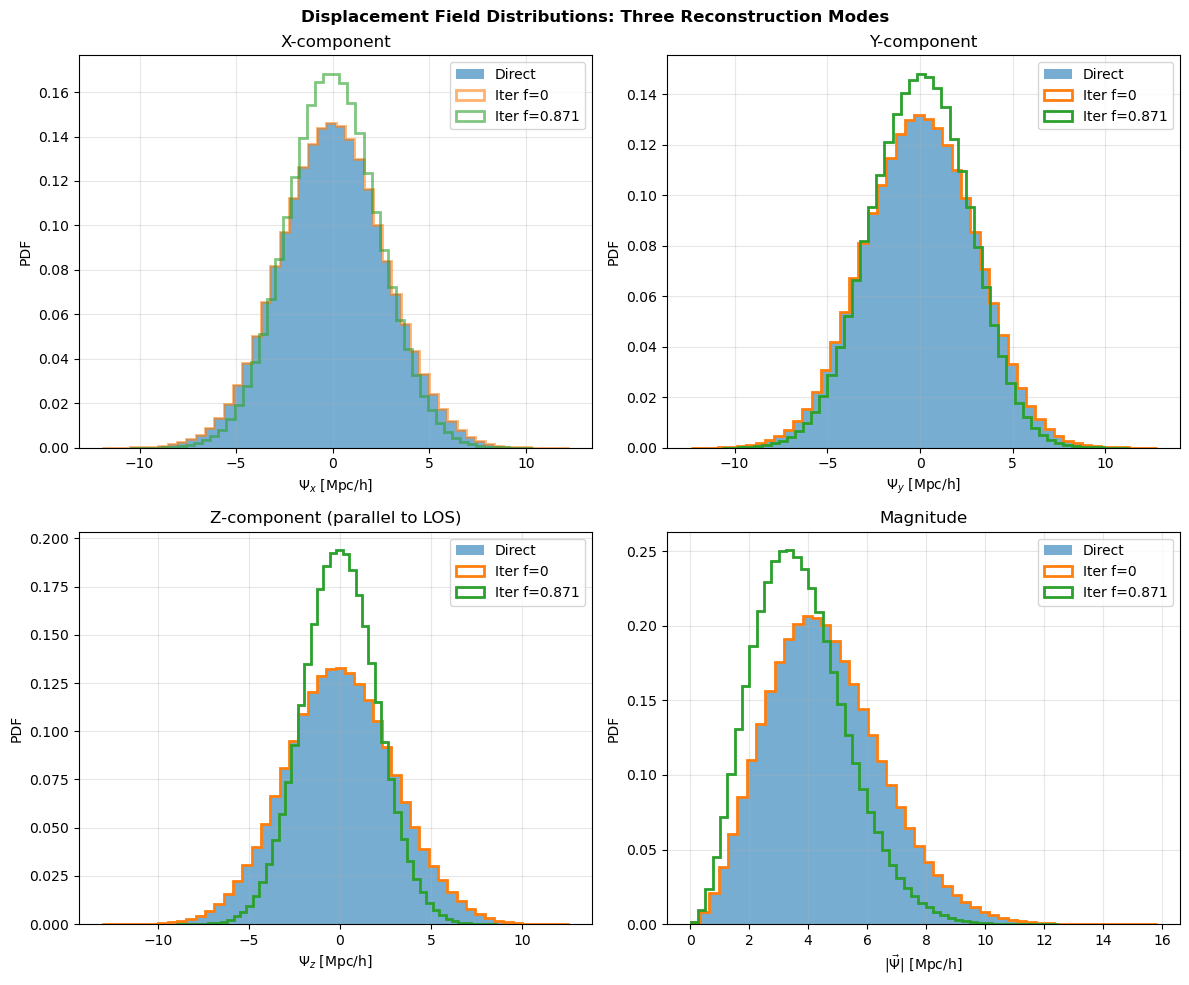

In [38]:
## Comparison of all three reconstruction modes

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# X-component
axs[0, 0].hist(psi_real[..., 0].flatten(), bins=50, density=True, label='Direct', alpha=0.6, histtype='stepfilled', linewidth=2)
axs[0, 0].hist(psi_iter_f0[..., 0].flatten(), bins=50, density=True, label='Iter f=0', alpha=0.6, histtype='step', linewidth=2)
axs[0, 0].hist(psi_iter_RSD[..., 0].flatten(), bins=50, density=True, label=f'Iter f={growth_rate:.3f}', alpha=0.6, histtype='step', linewidth=2)
axs[0, 0].set_xlabel(r'$\Psi_x$ [Mpc/h]')
axs[0, 0].set_ylabel('PDF')
axs[0, 0].set_title('X-component')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# Y-component
axs[0, 1].hist(psi_real[..., 1].flatten(), bins=50, density=True, label='Direct', alpha=0.6, histtype='stepfilled', linewidth=2)
axs[0, 1].hist(psi_iter_f0[..., 1].flatten(), bins=50, density=True, label='Iter f=0', histtype='step', linewidth=2)
axs[0, 1].hist(psi_iter_RSD[..., 1].flatten(), bins=50, density=True, label=f'Iter f={growth_rate:.3f}',  histtype='step', linewidth=2)
axs[0, 1].set_xlabel(r'$\Psi_y$ [Mpc/h]')
axs[0, 1].set_ylabel('PDF')
axs[0, 1].set_title('Y-component')
axs[0, 1].legend()
axs[0, 1].grid(alpha=0.3)

# Z-component
axs[1, 0].hist(psi_real[..., 2].flatten(), bins=50, density=True, label='Direct', alpha=0.6, histtype='stepfilled', linewidth=2)
axs[1, 0].hist(psi_iter_f0[..., 2].flatten(), bins=50, density=True, label='Iter f=0',  histtype='step', linewidth=2)
axs[1, 0].hist(psi_iter_RSD[..., 2].flatten(), bins=50, density=True, label=f'Iter f={growth_rate:.3f}', histtype='step', linewidth=2)
axs[1, 0].set_xlabel(r'$\Psi_z$ [Mpc/h]')
axs[1, 0].set_ylabel('PDF')
axs[1, 0].set_title('Z-component (parallel to LOS)')
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# Magnitude
psi_real_norm = np.linalg.norm(psi_real, axis=-1)
psi_iter_f0_norm = np.linalg.norm(psi_iter_f0, axis=-1)
psi_iter_RSD_norm = np.linalg.norm(psi_iter_RSD, axis=-1)

axs[1, 1].hist(psi_real_norm.flatten(), bins=50, density=True, label='Direct', alpha=0.6, histtype='stepfilled', linewidth=2)
axs[1, 1].hist(psi_iter_f0_norm.flatten(), bins=50, density=True, label='Iter f=0',  histtype='step', linewidth=2)
axs[1, 1].hist(psi_iter_RSD_norm.flatten(), bins=50, density=True, label=f'Iter f={growth_rate:.3f}', histtype='step', linewidth=2)
axs[1, 1].set_xlabel(r'$|\vec{\Psi}|$ [Mpc/h]')
axs[1, 1].set_ylabel('PDF')
axs[1, 1].set_title('Magnitude')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

fig.suptitle('Displacement Field Distributions: Three Reconstruction Modes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

$f=0$ is the same as real space, as expected. $f=0.8$ yields a smaller displacement, because interprets part of the clustering signal as RSD, but always returns the real space displacement estimation.

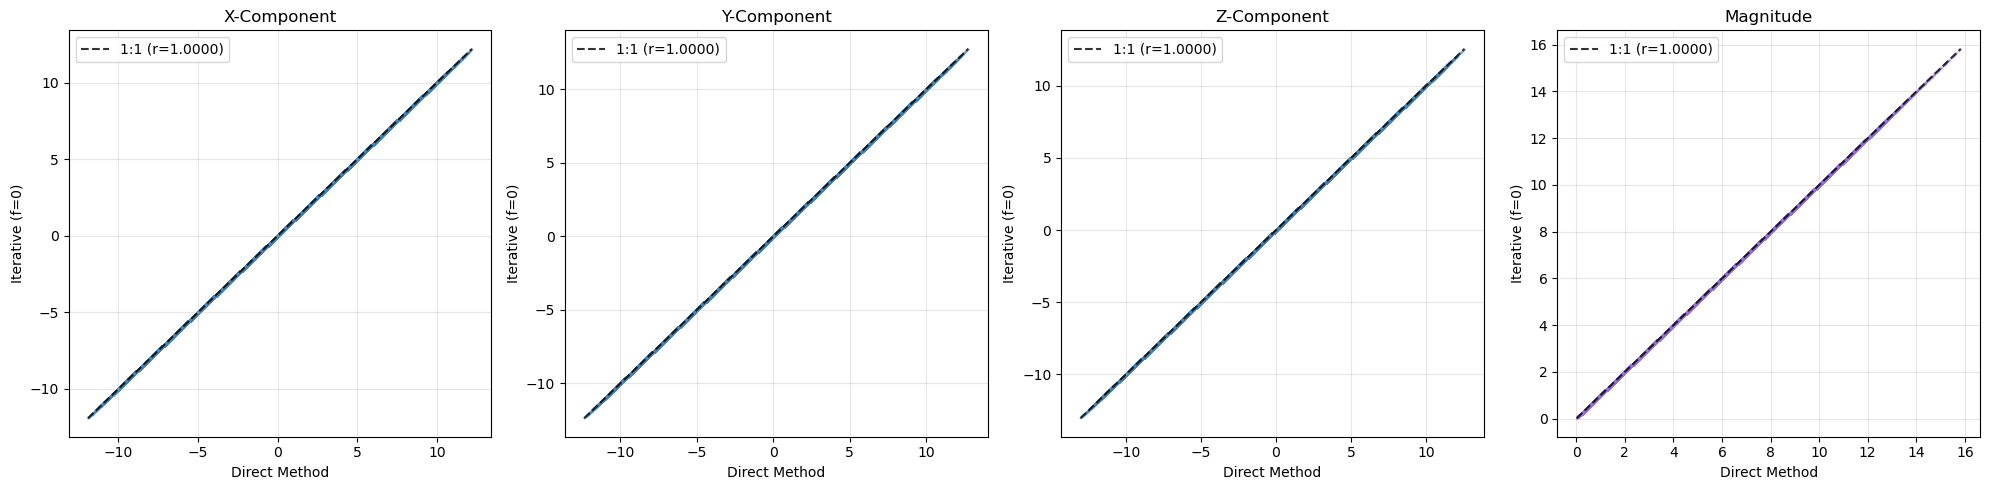

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Calcolo delle norme se non lo hai già fatto
psi_real_norm = np.linalg.norm(psi_real, axis=-1)
psi_iter_f0_norm = np.linalg.norm(psi_iter_f0, axis=-1)

fig, axs = plt.subplots(1, 4, figsize=(20, 5)) # Aumentato leggermente figsize per leggibilità
titles = ['X-Component', 'Y-Component', 'Z-Component', 'Magnitude']
colors = ['steelblue', 'steelblue', 'steelblue', 'mediumpurple']

for i in range(4):
    # Selezione dati
    if i < 3:
        x_data = psi_real[..., i].flatten()
        y_data = psi_iter_f0[..., i].flatten()
    else:
        x_data = psi_real_norm.flatten()
        y_data = psi_iter_f0_norm.flatten()
    
    # Calcolo correlazione
    corr = np.corrcoef(x_data, y_data)[0, 1]
    
    # Scatter plot
    axs[i].scatter(x_data, y_data, alpha=0.1, s=1, color=colors[i])
    
    # Linea 1:1
    lims = [min(x_data.min(), y_data.min()), max(x_data.max(), y_data.max())]
    axs[i].plot(lims, lims, 'k--', alpha=0.8, label=f'1:1 (r={corr:.4f})')
    
    # Estetica
    axs[i].set_xlabel('Direct Method')
    axs[i].set_ylabel('Iterative (f=0)')
    axs[i].set_title(titles[i])
    axs[i].legend(loc='upper left')
    axs[i].grid(True, alpha=0.3)

plt.suptitle('Direct vs Iterative (f=0) Displacement Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
## Statistical comparison: Kolmogorov-Smirnov test

from scipy.stats import ks_2samp

print("=" * 70)
print("Kolmogorov-Smirnov Test: Comparing displacement field distributions")
print("=" * 70)

# Compare pairs
pairs = [
    ("Direct", psi_real, "Iter f=0", psi_iter_f0),
    ("Direct", psi_real, f"Iter f={growth_rate:.4f}", psi_iter_RSD),
    ("Iter f=0", psi_iter_f0, f"Iter f={growth_rate:.4f}", psi_iter_RSD),
]

for label1, field1, label2, field2 in pairs:
    print(f"\n{label1} vs {label2}:")
    for i, comp in enumerate(['X', 'Y', 'Z']):
        ks_stat, p_val = ks_2samp(field1[..., i].flatten(), field2[..., i].flatten())
        print(f"  {comp}-component: KS={ks_stat:.6f}, p-value={p_val:.6e}")
    
    # Magnitude
    mag1 = np.linalg.norm(field1, axis=-1).flatten()
    mag2 = np.linalg.norm(field2, axis=-1).flatten()
    ks_stat, p_val = ks_2samp(mag1, mag2)
    print(f"  Magnitude:     KS={ks_stat:.6f}, p-value={p_val:.6e}")

print("=" * 70)

Kolmogorov-Smirnov Test: Comparing displacement field distributions

Direct vs Iter f=0:
  X-component: KS=0.000000, p-value=1.000000e+00
  Y-component: KS=0.000000, p-value=1.000000e+00
  Z-component: KS=0.000000, p-value=1.000000e+00
  Magnitude:     KS=0.000000, p-value=1.000000e+00

Direct vs Iter f=0.8712:
  X-component: KS=0.035969, p-value=0.000000e+00
  Y-component: KS=0.030623, p-value=0.000000e+00
  Z-component: KS=0.091344, p-value=0.000000e+00
  Magnitude:     KS=0.190686, p-value=0.000000e+00

Iter f=0 vs Iter f=0.8712:
  X-component: KS=0.035969, p-value=0.000000e+00
  Y-component: KS=0.030623, p-value=0.000000e+00
  Z-component: KS=0.091344, p-value=0.000000e+00
  Magnitude:     KS=0.190686, p-value=0.000000e+00


## Summary

This notebook demonstrates three different reconstruction modes using the FFTSolver:

1. **Direct (RealSpace)**: Solves for displacement field directly from density contrast in real space
2. **Iterative (f=0)**: Uses iterative FFT approach with zero growth rate (effective real space)
3. **Iterative (RSD)**: Uses iterative FFT approach with non-zero growth rate for RedshiftSpace corrections


